In [2]:
!ls ../llm_judge/configs_beir_chunks128

beir_nfcorpus.json  beir_scifact.json	  beir_webis_touche2020_v2.json
beir_scidocs.json   beir_trec_covid.json  wikipedia_beir_nq.json


In [3]:
CONFIG_DIR='../llm_judge/configs_beir_chunks128/'
RELEV_THRESHOLD=1
STEP_SIZE=128 # smaller chunk

In [4]:
from math import ceil

# chunks might be one sentence off
def doclen_to_bin(pos, step=STEP_SIZE, START_HEURISTIC_ERROR=32):
    return (START_HEURISTIC_ERROR + pos) // step

In [9]:
import json
import os
from tqdm.auto import tqdm
from flexneuart.io import FileWrapper

from collections import defaultdict

RESULTS_COPIED=False

for part_name, config_name in tqdm([
    ('wikipedia_beir_nq', 'wikipedia_beir_nq.json'),
    ('beir_scifact', 'beir_scifact.json'),
    ('beir_scidocs', 'beir_scidocs.json'),
    ('beir_trec_covid', 'beir_trec_covid.json'),
    ('beir_webis_touche2020_v2', 'beir_webis_touche2020_v2.json'),
    ('beir_nfcorpus', 'beir_nfcorpus.json'),
]):
    config = json.load(open(f'{CONFIG_DIR}/{config_name}')) 
    
    # Initially all results are stored in the collect_root, but for analysis we moved them to our centralized place
    if RESULTS_COPIED:
        data_root = '/disk3/collections/longp_results/relev_info'
    else:
        data_root = config['collect_root']
    
   
    data_file_path = f"{data_root}/{config['dataset']}/{config['output_subdir']}/{config['gpt_model_name']}/output.json"
    dt = json.load(open(data_file_path))  
    
    dir_name_raw = f'raw/{part_name}'
    os.makedirs(dir_name_raw, exist_ok=True)
    with FileWrapper(f'{dir_name_raw}/output.json.bz2', 'w') as out_f:
        json.dump(dt, out_f)    
    
    doc_lens_dict = {e['doc_id']:doclen_to_bin(e['doc_text_tok_len']) for e in dt}
    match_start_dict = {}
    for e in dt:
        start = -1 #config['chunking']['max_chunk_qty'] - 1
        for chunk_id, chunk in enumerate(e['judged_chunks']):
            if chunk['judgment'] >= RELEV_THRESHOLD:
                start = chunk_id
                break
        match_start_dict[e['doc_id']] = start
        
    dir_name = f'processed/{part_name}'
    os.makedirs(dir_name, exist_ok=True)
    with open(f'{dir_name}/doc_lens_dict.json', 'w') as out_f:
        json.dump(list(doc_lens_dict.items()), out_f)
    with open(f'{dir_name}/match_start_dict.json', 'w') as out_f:
        json.dump(list(match_start_dict.items()), out_f)       

  0%|          | 0/6 [00:00<?, ?it/s]

(array([347., 318.,  38.,  20.,   2.,   2.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
        12., 13., 14., 15., 16., 17., 18.]),
 <BarContainer object of 19 artists>)

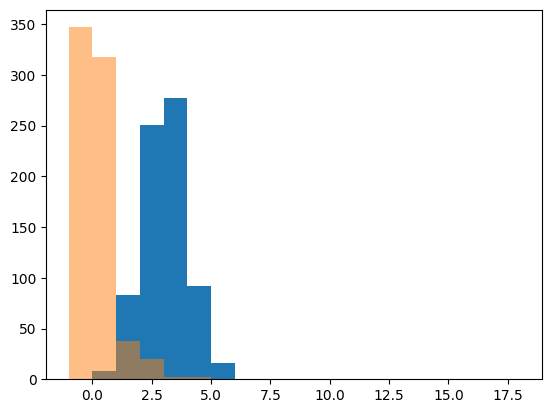

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
bins=[-1] + list(np.arange(config['chunking']['max_chunk_qty'] + 1))
plt.hist(doc_lens_dict.values(), bins=bins, alpha=1)
plt.hist(match_start_dict.values(), bins=bins, alpha=0.5)

In [7]:
#doc_lens_dict

In [ ]:
#match_start_dict

In [ ]:
arr=np.array(list(match_start_dict.values()))

In [ ]:
len(arr), sum(arr==0)/len(arr)

In [ ]:
match_start_dict.values()